In [14]:
from collections import defaultdict
from itertools import combinations
import baltic as bt
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from scipy.stats import chisquare

# segment reassortment rate code
from treetime import TreeTime, TreeTimeError, utils
from dendropy import Tree
from Bio import SeqIO
import random
from datetime import datetime
import math
import os
import re

In [2]:
tree_folder = "prepped"
clades = ['na_avian', 'swine', 'human', 'canine', 'equine']

In [3]:
host_trees = {}

for clade in clades:
    
    tree = bt.loadNewick(f"{clade}/{tree_folder}/summary-95.nwk", absoluteTime= False)
    
    host_trees[f"{clade}"] = tree
    

In [8]:
host_trees

{'na_avian': <baltic.baltic.tree at 0x112901ba0>,
 'swine': <baltic.baltic.tree at 0x17eea8eb0>,
 'human': <baltic.baltic.tree at 0x17f278640>,
 'canine': <baltic.baltic.tree at 0x17f361ed0>,
 'equine': <baltic.baltic.tree at 0x17f40bee0>}

In [4]:
reassortment_count = {}
gene_segment_counts = {name: {} for name in host_trees.keys()}
num_segment_counts = {name: {} for name in host_trees.keys()}
leaf_list = {name: [] for name in host_trees.keys()}
nodes = {}
leaves = {}

# dictionary for segment co-occurrences
segment_pair_counts = {name: defaultdict(lambda: defaultdict(int)) for name in host_trees.keys()}

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name, tree in host_trees.items():
    
    leaf = []
    node_count = 0
    leaf_count = 0
    count = 0
    tree_segment_counts = {segment: 0 for segment in gene_segments}
    num_segments_involved = {i: 0 for i in range(1, 8)}
    
    for k in tree.Objects:
        if k.traits.get('is_reassorted'):
            
            raw_segments = k.traits["rea"]
            is_uncertain = all([g_str.startswith('_') for g_str in raw_segments.split('-')])
            
            lst = [seg.split("(")[0].lstrip('_') for seg in raw_segments.split("-")]
            num_segments_involved[len(lst)] += 1
            count += 0.5 if is_uncertain else 1
            
            for seg in lst:
                tree_segment_counts[seg] += 0.5 if seg.startswith('_') else 1
                
            if k.is_node():
                node_count += 0.5 if is_uncertain else 1
            else:
                leaf_count += 0.5 if is_uncertain else 1
            
            # counting segment pairs (combinations of 2)
            if len(lst) > 1:
                for seg1, seg2 in combinations(lst, 2):
                    # increment both directions for easy access
                    segment_pair_counts[name][seg1][seg2] += 1
                    segment_pair_counts[name][seg2][seg1] += 1

    reassortment_count[name] = count
    nodes[name] = node_count
    leaves[name] = leaf_count
    gene_segment_counts[name] = tree_segment_counts
    num_segment_counts[name] = num_segments_involved

In [5]:
gene_segment_counts

{'na_avian': {'NA': 173,
  'NP': 131,
  'NS': 100,
  'PB1': 111,
  'PB2': 117,
  'MP': 99,
  'PA': 183},
 'swine': {'NA': 59,
  'NP': 93,
  'NS': 93,
  'PB1': 63,
  'PB2': 81,
  'MP': 107,
  'PA': 99},
 'human': {'NA': 2, 'NP': 5, 'NS': 4, 'PB1': 3, 'PB2': 6, 'MP': 3, 'PA': 5},
 'canine': {'NA': 1, 'NP': 2, 'NS': 2, 'PB1': 2, 'PB2': 1, 'MP': 2, 'PA': 1},
 'equine': {'NA': 2, 'NP': 0, 'NS': 2, 'PB1': 1, 'PB2': 0, 'MP': 0, 'PA': 1}}

In [6]:
num_segment_counts

{'na_avian': {1: 444, 2: 117, 3: 38, 4: 16, 5: 8, 6: 3, 7: 0},
 'swine': {1: 196, 2: 56, 3: 30, 4: 13, 5: 15, 6: 7, 7: 4},
 'human': {1: 5, 2: 0, 3: 2, 4: 0, 5: 1, 6: 2, 7: 0},
 'canine': {1: 6, 2: 1, 3: 1, 4: 0, 5: 0, 6: 0, 7: 0},
 'equine': {1: 4, 2: 1, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0}}

In [7]:
# we need to calculate the molecular rate for backbone tree to get rate in units of rea event / years

def parse_dates(aln_path: str):
    records = SeqIO.parse(aln_path, 'fasta')
    dates = {}
    for record in records:
        name = record.name
        # date_str = name.split('|')[-1]
        date = None
        for token in name.split('|'):
            if re.fullmatch(r'[\d\-/]{4,}', token) and not re.fullmatch(r'\d{5,}', token):
                if token.count('/') == 2:
                    date = datetime.strptime(token, '%m/%d/%Y')
                elif token.count('/') == 1:
                    date = datetime.strptime(token, '%m/%Y')
                elif token.count('-') == 2:
                    date = datetime.strptime(token, '%Y-%m-%d')
                elif token.count('-') == 1:
                    date = datetime.strptime(token, '%Y-%m')
                else:
                    date = datetime.strptime(token, '%Y')
        if not date:
            pass
        else:
            dec_date = date.year + ((date.month - 1) * 30 + date.day) / 365.0
            dates[name] = dec_date
            
    return dates


# from treesort/options.py

def estimate_clock_rate(tree_path: str, aln_path: str, outdir='.') -> (float, float):
    
    # This code was adapted from the  'estimate_clock_model' method in the treetime/wrappers.py.
    tree: Tree = Tree.get(path=tree_path, schema='newick', preserve_underscores=True)
    if len(tree.leaf_nodes()) > 1000:
        tree_path = os.path.join(outdir, os.path.split(tree_path)[-1] + '.sample1k.tre')
        taxa_labels = [t.label for t in tree.taxon_namespace]
        random.shuffle(taxa_labels)
        subtree: Tree = tree.extract_tree_with_taxa_labels(taxa_labels[:1000])
        subtree.write(path=tree_path, schema='newick')

    dates = parse_dates(aln_path)
    
    try:
        timetree = TreeTime(dates=dates, tree=tree_path, aln=aln_path, gtr='JC69', verbose=-1)  # TODO: JC->GTR?
    except TreeTimeError as e:
        parser.error(f"TreeTime exception on the input files {tree_path} and {aln_path}: {e}\n "
                     f"Please make sure that the specified alignments and trees are correct.")
                     
    timetree.clock_filter(n_iqd=3, reroot='least-squares')
    timetree.use_covariation = True
    timetree.reroot()
    timetree.get_clock_model(covariation=True)
    r_val = timetree.clock_model['r_val']
    d2d = utils.DateConversion.from_regression(timetree.clock_model)
    clock_rate = round(d2d.clock_rate, 7)
    
    return d2d.clock_rate, r_val

In [9]:
tree_folder = "prepped"
clades = ['na_avian', 'swine', 'human', 'canine', 'equine']

tree_paths = {}
aln_paths = {}

for clade in clades:
    
    tree = f"{clade}/{tree_folder}/summary-95.nwk"
    aln = f"{clade}/{tree_folder}/h3nx_ha.fasta"
    
    tree_paths[f"{clade}"] = tree
    aln_paths[f"{clade}"] = aln

In [16]:
clock_rates = {}

for host in clades:

    clock_rate, r_val = estimate_clock_rate(tree_paths[host], aln_paths[host])
    clock_rates[host] = clock_rate

In [17]:
clock_rates

{'na_avian': 0.0013373121786318743,
 'swine': 0.0038428316817441964,
 'human': 0.0037585733721550727,
 'canine': 0.0017366935435119619,
 'equine': 0.0017040478904762576}

In [24]:
# computes reassortment rates for all segments

def compute_rea_rates_all_segments(annotated_tree, reassorting_seg_counts, evol_rate, ignore_top_edges=1):
   
    edge_cutoff = None
    
    def top_1(tree, ignore_top_edges):
        
        edge_cutoff = math.inf
        edge_lengths = sorted([node.length for node in tree.Objects if node.length])
        top_percentile = int(round(len(edge_lengths) * (1.0 - ignore_top_edges / 100)))
        edge_cutoff = edge_lengths[top_percentile - 1]
    
        return(edge_cutoff)
    
    if ignore_top_edges > 0:
        edge_cutoff = top_1(annotated_tree, ignore_top_edges)

    tree_length = 0.0

    for node in annotated_tree.Objects:
        if node.parent is None:
            continue  # Skip root
        if node.length >= edge_cutoff:
            continue  # Skip longest edges

        tree_length += node.length
        
    rea_rates = {seg: count / tree_length * evol_rate
                 for seg, count in reassorting_seg_counts.items()}


    return rea_rates


In [25]:
host_rea_rates = {}

for clade in clades:

    rea_rates = compute_rea_rates_all_segments(host_trees[clade], gene_segment_counts[clade], clock_rates[clade], ignore_top_edges=1)
    host_rea_rates[clade] = rea_rates

In [26]:
host_rea_rates

{'na_avian': {'NA': 0.06637299089512398,
  'NP': 0.05025931680497828,
  'NS': 0.038365890690823114,
  'PB1': 0.042586138666813655,
  'PB2': 0.04488809210826304,
  'MP': 0.03798223178391488,
  'PA': 0.0702095799642063},
 'swine': {'NA': 0.021648060903601427,
  'NP': 0.03412321464465987,
  'NS': 0.03412321464465987,
  'PB1': 0.0231157260496083,
  'PB2': 0.029720219206639243,
  'MP': 0.03926004265568394,
  'PA': 0.036324712363670186},
 'human': {'NA': 0.008364467279748685,
  'NP': 0.02091116819937171,
  'NS': 0.01672893455949737,
  'PB1': 0.012546700919623026,
  'PB2': 0.025093401839246052,
  'MP': 0.012546700919623026,
  'PA': 0.02091116819937171},
 'canine': {'NA': 0.004240595652468545,
  'NP': 0.00848119130493709,
  'NS': 0.00848119130493709,
  'PB1': 0.00848119130493709,
  'PB2': 0.004240595652468545,
  'MP': 0.00848119130493709,
  'PA': 0.004240595652468545},
 'equine': {'NA': 0.006421766654015399,
  'NP': 0.0,
  'NS': 0.006421766654015399,
  'PB1': 0.0032108833270076994,
  'PB2': 0.

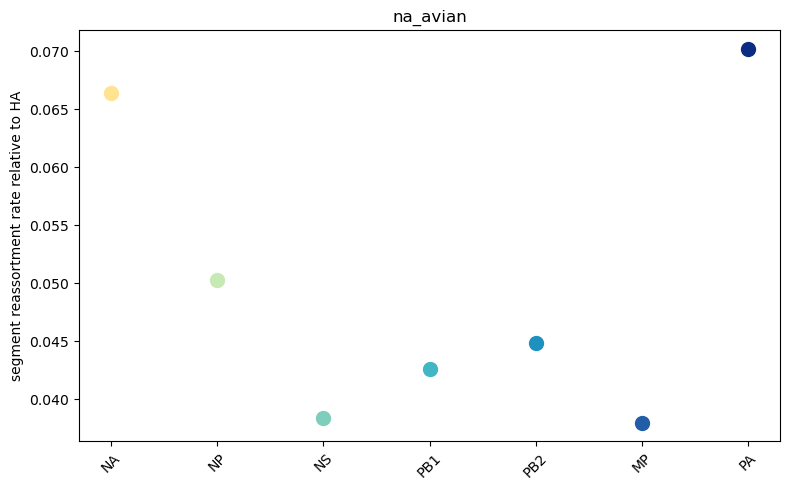

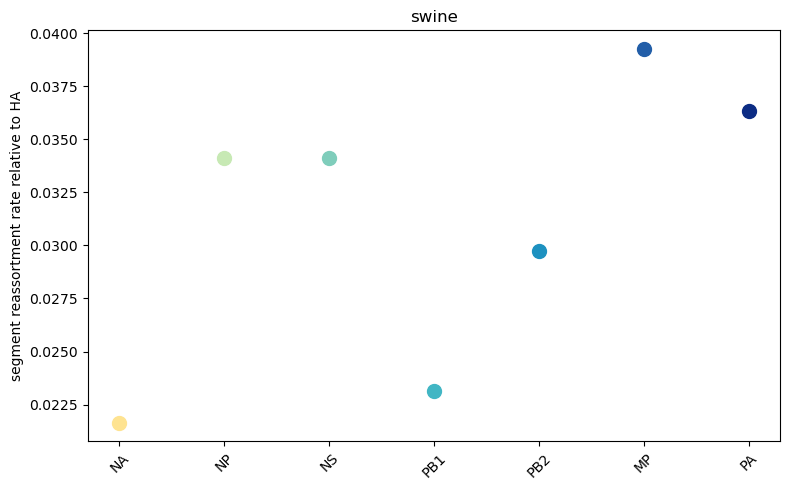

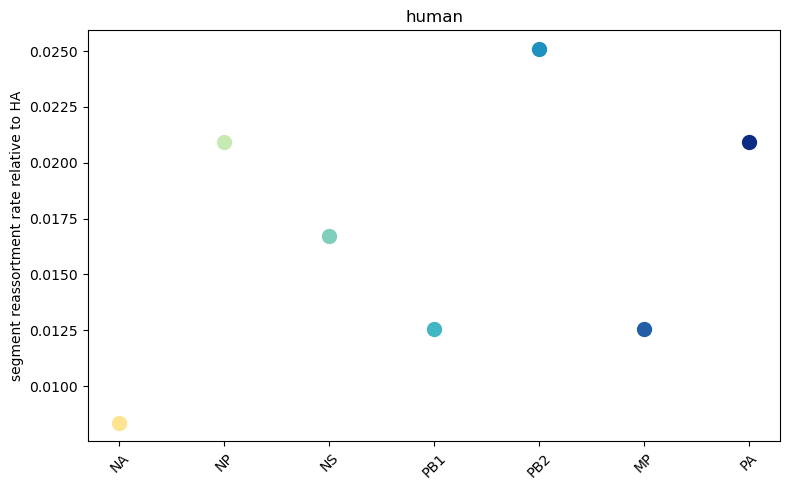

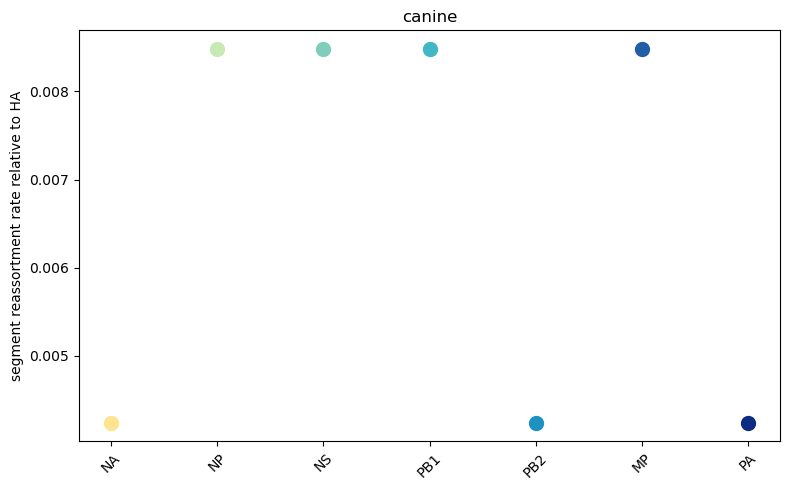

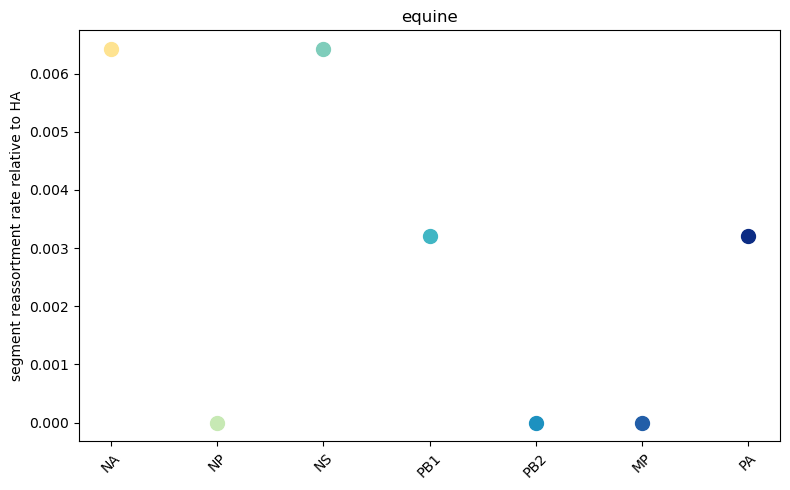

In [28]:
genes = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']
colors = ['#fee391', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84']

for clade in clades:

    rates = [host_rea_rates[clade].get(gene, 0) for gene in genes]

    plt.figure(figsize=(8, 5))

    for i, gene in enumerate(genes):
        plt.scatter(i, rates[i], color=colors[i], s=100)  # s=100 is point size

    plt.title(clade)
    plt.xticks(range(len(genes)), genes, rotation=45)
    plt.ylabel('segment reassortment rate relative to HA')
    plt.tight_layout()
    plt.show()
